# Product Analysis

This notebook analyzes product-level data, including product popularity, category distributions, and product lifecycle patterns.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [9]:
folder_path = '../../data/data1031'
file = 'order_commodity_result.csv'
file_path = os.path.join(folder_path, file)
columns = ["create_hour", "dept_id",
           "is_top_commodity_coffee_tag", 
           "is_top_commodity_not_coffee_tag", 
           "coffee_commodity_name", 
           "drink_not_coffee_commodity_name",
           "food_commodity_name",
           "other_not_coffee_commodity_name"]
# only read the columns in the list
products = pd.read_csv(file_path, usecols=columns)
#de-duplicate
products = products.drop_duplicates()
products['date'] = pd.to_datetime(products['create_hour'],
                                  format='%Y-%m-%d %H').dt.date
products = products.drop(columns=['create_hour'])                                  
products.head()

,is_top_commodity_coffee_tag,is_top_commodity_not_coffee_tag,dept_id,coffee_commodity_name,food_commodity_name,drink_not_coffee_commodity_name,other_not_coffee_commodity_name,date
0,0.0,NaN,238,香草拿铁_0,NaN,NaN,NaN,2021-05-29
1,0.0,NaN,238,拿铁_1,NaN,NaN,NaN,2021-05-29
2,1.0,NaN,218,拿铁_13,NaN,NaN,NaN,2021-06-29
3,NaN,0.0,218,NaN,大福_2,NaN,NaN,2021-06-29
4,NaN,0.0,218,NaN,半熟芝士_5,NaN,NaN,2021-06-29


In [10]:
print('number of stores:')
print(len(products['dept_id'].unique()))


number of stores:
260


In [11]:
products["date"] = pd.to_datetime(products["date"])
# Get unique names for top commodity coffee
top_coffee_names = products[products['is_top_commodity_coffee_tag'] == 1.0]['coffee_commodity_name'].dropna().unique()
not_top_coffee_names = np.setdiff1d(
    products[products['is_top_commodity_coffee_tag'] == 0.0]['coffee_commodity_name'].dropna().unique(),
    top_coffee_names
)


# Get unique names for top commodity not coffee
top_not_coffee_mask = products['is_top_commodity_not_coffee_tag'] == 1.0
top_not_coffee_food = products[top_not_coffee_mask]['food_commodity_name'].dropna().unique()
top_not_coffee_drink = products[top_not_coffee_mask]['drink_not_coffee_commodity_name'].dropna().unique()
top_not_coffee_other = products[top_not_coffee_mask]['other_not_coffee_commodity_name'].dropna().unique()
top_not_coffee_names = np.concatenate([top_not_coffee_food, top_not_coffee_drink, top_not_coffee_other])
# Get unique names for non-top commodity not coffee: not_top_not_coffee_names
not_top_not_coffee_mask = products['is_top_commodity_not_coffee_tag'] == 0.0
not_top_not_coffee_food = products[not_top_not_coffee_mask]['food_commodity_name'].dropna().unique()
not_top_not_coffee_drink = products[not_top_not_coffee_mask]['drink_not_coffee_commodity_name'].dropna().unique()
not_top_not_coffee_other = products[not_top_not_coffee_mask]['other_not_coffee_commodity_name'].dropna().unique()
not_top_not_coffee_names = np.concatenate([not_top_not_coffee_food, not_top_not_coffee_drink, not_top_not_coffee_other])

# Get unique names for food commodity
food_names = products['food_commodity_name'].dropna().unique()

#print("Non-Top Commodity Coffee Names:")
#print(not_top_coffee_names)
print(f"\nNumber of non-top coffee commodities: {len(not_top_coffee_names)}")
#print("Top Commodity Coffee Names:")
#print(top_coffee_names)
print(f"\nNumber of top coffee commodities: {len(top_coffee_names)}")

#print("Non-Top Commodity Not Coffee Names:")
#print(not_top_not_coffee_names)
print(f"\nNumber of non-top non-coffee commodities: {len(not_top_not_coffee_names)}")
#print("\nTop Commodity Not Coffee Names:")
#print(top_not_coffee_names)
print(f"\nNumber of top non-coffee commodities: {len(top_not_coffee_names)}")

#print("\nFood Commodity Names:")
#print(food_names)
print(f"\nNumber of food commodities: {len(food_names)}")

# Find first appearance date for top commodities - fixed approach
top_coffee_first_appearance = products[products['is_top_commodity_coffee_tag'] == 1.0].groupby('coffee_commodity_name').agg({'date': 'min'}).reset_index()
top_coffee_first_appearance.columns = ['product_name', 'first_appearance']

# For top non-coffee, handle each column separately and combine
top_not_coffee_first_appearance_list = []
for col in ['drink_not_coffee_commodity_name', 'other_not_coffee_commodity_name']:
    temp_df = products[products['is_top_commodity_not_coffee_tag'] == 1.0][[col, 'date']].dropna()
    temp_df = temp_df.groupby(col).agg({'date': 'min'}).reset_index()
    temp_df.columns = ['product_name', 'first_appearance']
    top_not_coffee_first_appearance_list.append(temp_df)

top_not_coffee_first_appearance = pd.concat(top_not_coffee_first_appearance_list, ignore_index=True)

# sort by first_appearance
top_coffee_first_appearance = top_coffee_first_appearance.sort_values(by='first_appearance')
top_not_coffee_first_appearance = top_not_coffee_first_appearance.sort_values(by='first_appearance')
print("\nFirst Appearance - Top Coffee Commodities:")
top_coffee_first_appearance

print("\nFirst Appearance - Top Non-Coffee Commodities:")
top_not_coffee_first_appearance


Number of non-top coffee commodities: 78

Number of top coffee commodities: 19

Number of non-top non-coffee commodities: 351

Number of top non-coffee commodities: 14

Number of food commodities: 103

First Appearance - Top Coffee Commodities:


,product_name,first_appearance
18,香草拿铁_0,2020-06-01
16,美式_5,2020-06-01
2,加浓美式_1,2020-06-01
10,拿铁_11,2020-06-01
11,拿铁_13,2020-06-01
6,厚乳拿铁_5,2020-09-07
7,厚乳拿铁_6,2020-09-07
12,澳瑞白_1,2020-10-01
5,厚乳拿铁_16,2020-11-01
15,红茶拿铁_2,2021-01-11



First Appearance - Top Non-Coffee Commodities:


,product_name,first_appearance
0,厚乳奶茶_0,2020-10-01
8,芋泥布丁,2020-10-15
4,桂花乌龙茶,2020-12-14
9,阿华田厚乳_1,2021-01-04
7,胶原酸奶冻_4,2021-03-08
2,杨枝甘露_2,2021-04-06
3,杨枝甘露_4,2021-04-06
5,满杯桃桃_0,2021-05-01
6,瑞纳冰_2,2021-06-10
1,巧克力_1,2021-12-13


In [12]:
# in top_coffee_first_appearance, selecte those whose product_name contain "厚乳拿铁"
top_coffee_first_appearance[top_coffee_first_appearance['product_name'].str.contains('厚乳拿铁')]

,product_name,first_appearance
6,厚乳拿铁_5,2020-09-07
7,厚乳拿铁_6,2020-09-07
5,厚乳拿铁_16,2020-11-01
8,厚乳拿铁_7,2021-02-01
3,厚乳拿铁_1,2021-05-10
4,厚乳拿铁_15,2021-12-01


In [13]:
np.sort(products[products['is_top_commodity_coffee_tag'] == 0.0]['coffee_commodity_name'].dropna().unique())

array(['丝绒拿铁_0', '丝绒拿铁_1', '丝绒拿铁_2', '丝绒拿铁_4', '丝绒拿铁_5', '丝绒拿铁_6',
       '冰萃咖啡_0', '冰萃咖啡_1', '冰萃咖啡_2', '冰萃咖啡_3', '冰萃咖啡_4', '加浓美式_0',
       '加浓美式_1', '加浓美式_3', '卡布奇诺_0', '厚乳拿铁_0', '厚乳拿铁_1', '厚乳拿铁_11',
       '厚乳拿铁_12', '厚乳拿铁_13', '厚乳拿铁_14', '厚乳拿铁_15', '厚乳拿铁_16', '厚乳拿铁_17',
       '厚乳拿铁_18', '厚乳拿铁_2', '厚乳拿铁_3', '厚乳拿铁_4', '厚乳拿铁_5', '厚乳拿铁_7',
       '拿铁_0', '拿铁_1', '拿铁_12', '拿铁_13', '拿铁_14', '拿铁_15', '拿铁_16',
       '拿铁_17', '拿铁_18', '拿铁_2', '拿铁_3', '拿铁_4', '拿铁_5', '拿铁_8',
       '提拉米苏爱摩卡', '摩卡', '椰青冰萃', '气泡美式_0', '气泡美式_1', '气泡美式_2', '气泡美式_3',
       '气泡美式_4', '澳瑞白_1', '澳瑞白_2', '澳瑞白_3', '澳瑞白_4', '澳瑞白_5', '焦糖玛奇朵_5',
       '燕麦拿铁_0', '燕麦拿铁_1', '燕麦拿铁_2', '燕麦拿铁_3', '燕麦拿铁_4', '燕麦拿铁_5',
       '燕麦拿铁_6', '燕麦拿铁_7', '燕麦拿铁_8', '生椰拿铁_1', '生椰拿铁_2', '生椰拿铁_3',
       '生椰拿铁_4', '生椰拿铁_5', '生椰拿铁_6', '生椰爱摩卡', '红茶拿铁_0', '红茶拿铁_1',
       '红茶拿铁_2', '绯红白摩卡', '美式_0', '美式_1', '美式_2', '美式_3', '美式_4', '美式_5',
       '美式_7', '香草拿铁_0', '香草拿铁_1', '鸳鸯拿铁_0', '鸳鸯拿铁_1', '鸳鸯拿铁_2', '鸳鸯拿铁_3',
       '黑摩卡', '黑糖拿铁'], dtype=o

In [14]:
products[products['coffee_commodity_name']=='丝绒拿铁_2'][['coffee_commodity_name','is_top_commodity_coffee_tag']].drop_duplicates()


,coffee_commodity_name,is_top_commodity_coffee_tag
11,丝绒拿铁_2,1.0
632,丝绒拿铁_2,0.0


/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


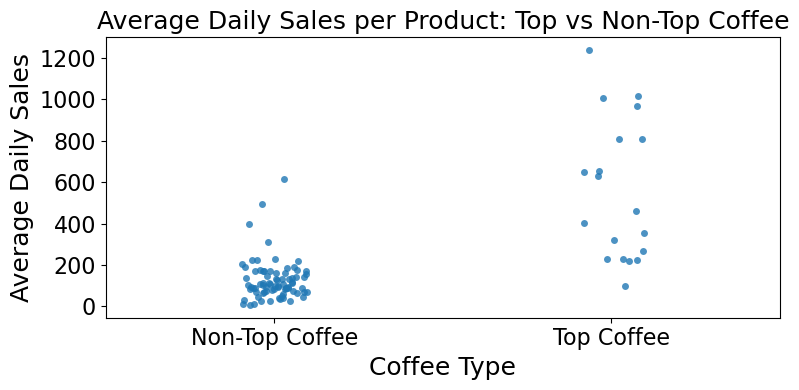

In [15]:
# Compare average daily sales for Top vs Non-Top Coffee
# Filter coffee records only
df_coffee = products[products['coffee_commodity_name'].notna()].copy()

# Mark each product as 'top' or 'non-top'
df_coffee['is_top'] = df_coffee['coffee_commodity_name'].isin(top_coffee_names)
df_coffee['kind'] = df_coffee['is_top'].map({True: 'Top Coffee', False: 'Non-Top Coffee'})

# Count daily sales per product
daily_counts = (
    df_coffee.groupby(['coffee_commodity_name', 'kind', 'date'])
    .size()
    .reset_index(name='daily_sales')
)

# Compute average daily sales per product
df_avg = (
    daily_counts.groupby(['coffee_commodity_name', 'kind'])['daily_sales']
    .mean()
    .reset_index(name='avg_daily_sales')
)

# Plot
plt.figure(figsize=(8, 4))
sns.stripplot(
    data=df_avg,
    x='kind', y='avg_daily_sales',
    dodge=True, jitter=True, alpha=0.8, zorder=1
)
plt.title('Average Daily Sales per Product: Top vs Non-Top Coffee', fontsize=18)
plt.ylabel('Average Daily Sales', fontsize=18)
plt.xlabel('Coffee Type', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('top_vs_non_top_coffee_sales.pdf', dpi=300)
plt.show();

/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


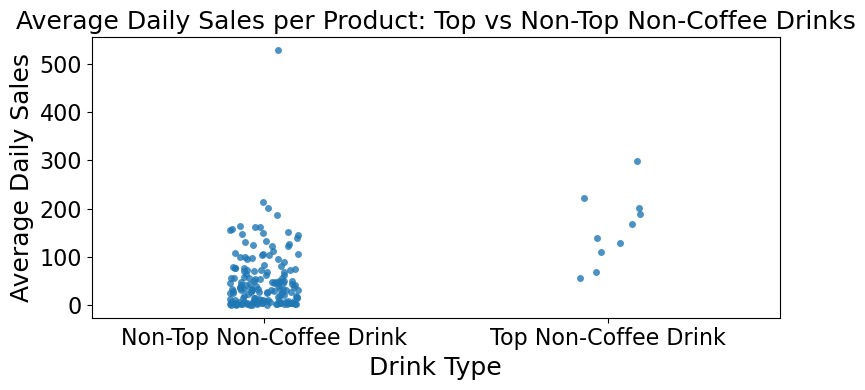

In [16]:
# Compare average daily sales for Top vs Non-Top Non-Coffee Drinks
# Only consider drinks, not coffee (exclude 'coffee_commodity_name')
df_drink = products[
    products['drink_not_coffee_commodity_name'].notna()
].copy()

# Mark each drink as 'top' or 'non-top'
df_drink['is_top'] = df_drink['drink_not_coffee_commodity_name'].isin(top_not_coffee_names)
df_drink['kind'] = df_drink['is_top'].map({True: 'Top Non-Coffee Drink', False: 'Non-Top Non-Coffee Drink'})

# Count daily sales per product
daily_drink_counts = (
    df_drink.groupby(['drink_not_coffee_commodity_name', 'kind', 'date'])
    .size()
    .reset_index(name='daily_sales')
)

# Compute average daily sales per product
df_drink_avg = (
    daily_drink_counts.groupby(['drink_not_coffee_commodity_name', 'kind'])['daily_sales']
    .mean()
    .reset_index(name='avg_daily_sales')
)

# Plot
plt.figure(figsize=(8, 4))
sns.stripplot(
    data=df_drink_avg,
    x='kind', y='avg_daily_sales',
    dodge=True, jitter=True, alpha=0.8, zorder=1
)
plt.title('Average Daily Sales per Product: Top vs Non-Top Non-Coffee Drinks', fontsize=18)
plt.ylabel('Average Daily Sales', fontsize=18)
plt.xlabel('Drink Type', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('top_vs_non_top_non-coffee_sales.pdf', dpi=300)
plt.show();

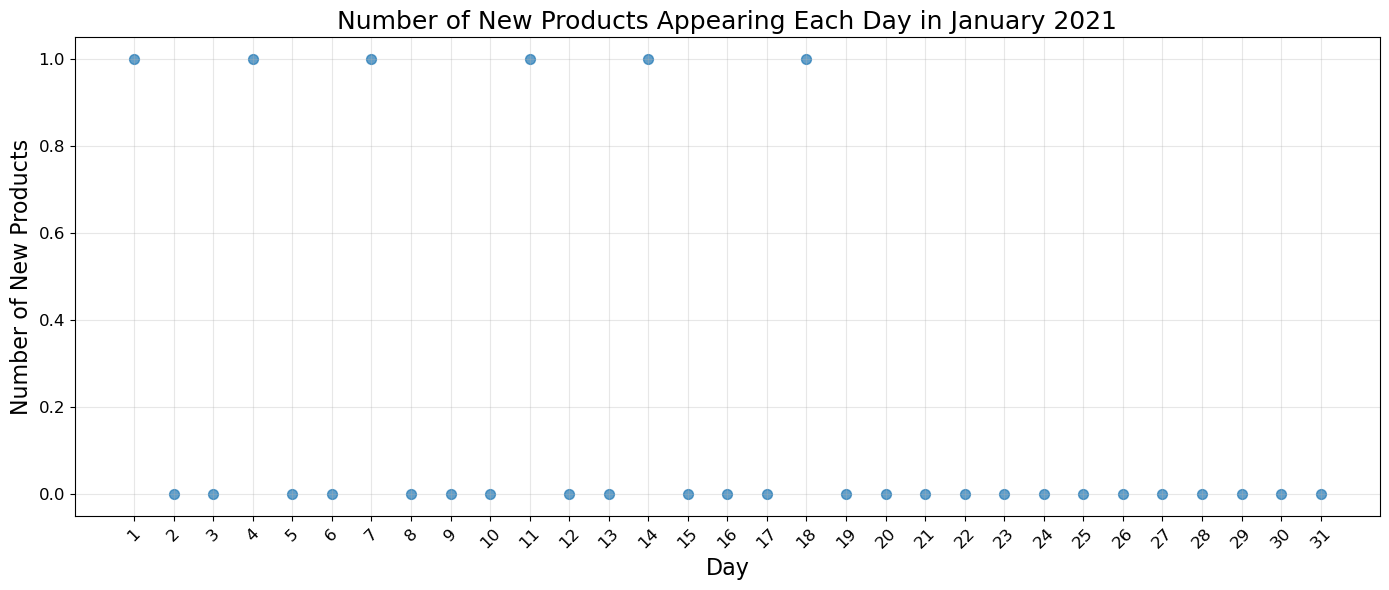

In [17]:
# Collect all products from all product name columns
all_products = []

# Coffee products
coffee_products = products[products['coffee_commodity_name'].notna()][['coffee_commodity_name', 'date']].copy()
coffee_products.columns = ['product_name', 'date']
all_products.append(coffee_products)

# Drink not coffee products
drink_products = products[products['drink_not_coffee_commodity_name'].notna()][['drink_not_coffee_commodity_name', 'date']].copy()
drink_products.columns = ['product_name', 'date']
all_products.append(drink_products)

# Food products
food_products = products[products['food_commodity_name'].notna()][['food_commodity_name', 'date']].copy()
food_products.columns = ['product_name', 'date']
all_products.append(food_products)

# Other not coffee products
other_products = products[products['other_not_coffee_commodity_name'].notna()][['other_not_coffee_commodity_name', 'date']].copy()
other_products.columns = ['product_name', 'date']
all_products.append(other_products)

# Combine all products
all_products_df = pd.concat(all_products, ignore_index=True)

# Find first appearance date for each product
first_appearance = all_products_df.groupby('product_name')['date'].min().reset_index()
first_appearance.columns = ['product_name', 'first_appearance_date']

# Filter for 2021-01
first_appearance['first_appearance_date'] = pd.to_datetime(first_appearance['first_appearance_date'])
jan_2021_start = pd.Timestamp('2021-01-01')
jan_2021_end = pd.Timestamp('2021-01-31')
jan_2021_new_products = first_appearance[
    (first_appearance['first_appearance_date'] >= jan_2021_start) &
    (first_appearance['first_appearance_date'] <= jan_2021_end)
]

# Count new products per day
new_products_per_day = jan_2021_new_products.groupby('first_appearance_date').size().reset_index(name='count')
new_products_per_day.columns = ['date', 'new_products_count']

# Create a complete date range for January 2021 to include days with 0 new products
date_range = pd.date_range(start='2021-01-01', end='2021-01-31', freq='D')
complete_dates = pd.DataFrame({'date': date_range})
new_products_per_day = complete_dates.merge(new_products_per_day, on='date', how='left')
new_products_per_day['new_products_count'] = new_products_per_day['new_products_count'].fillna(0).astype(int)

# Plot
plt.figure(figsize=(14, 6))
plt.scatter(new_products_per_day['date'], new_products_per_day['new_products_count'], 
            s=50, alpha=0.7)
plt.title('Number of New Products Appearing Each Day in January 2021', fontsize=18)
plt.xlabel('Day', fontsize=16)
plt.ylabel('Number of New Products', fontsize=16)
# Extract day from date for x-axis labels
plt.xticks(new_products_per_day['date'], 
           new_products_per_day['date'].dt.day, 
           rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();


/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

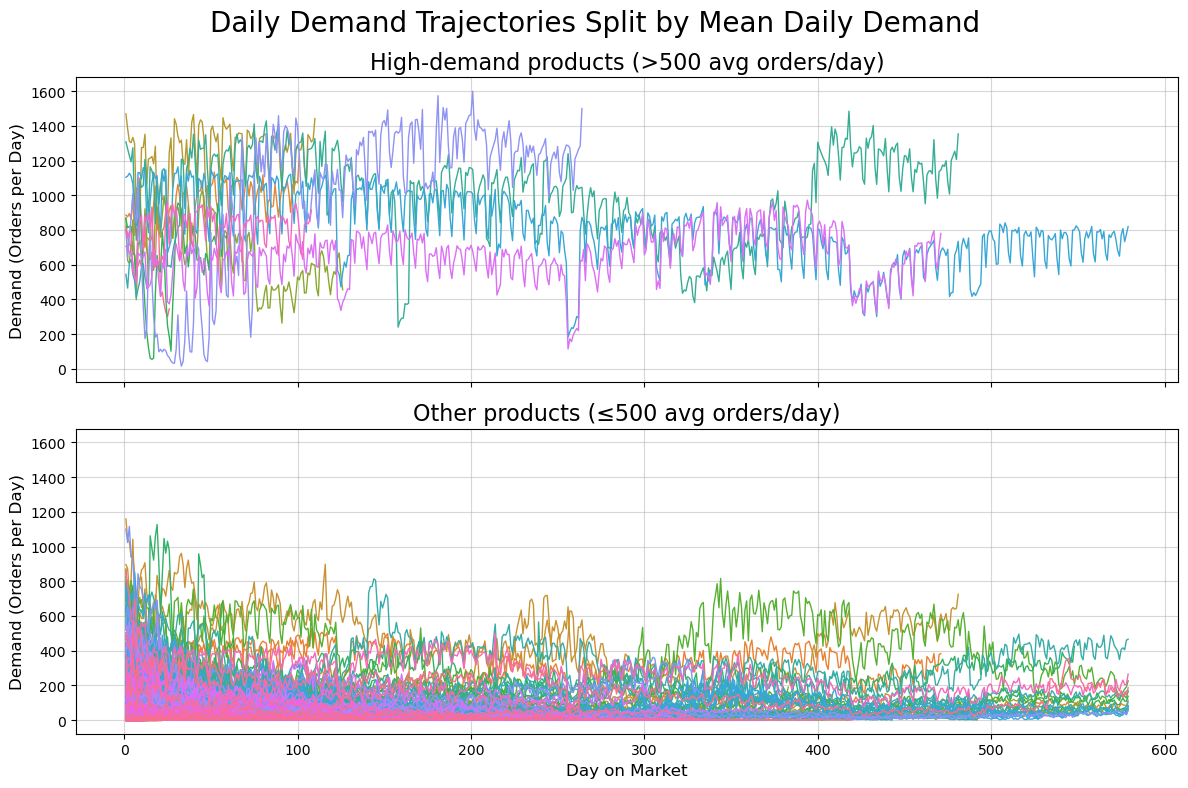

/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


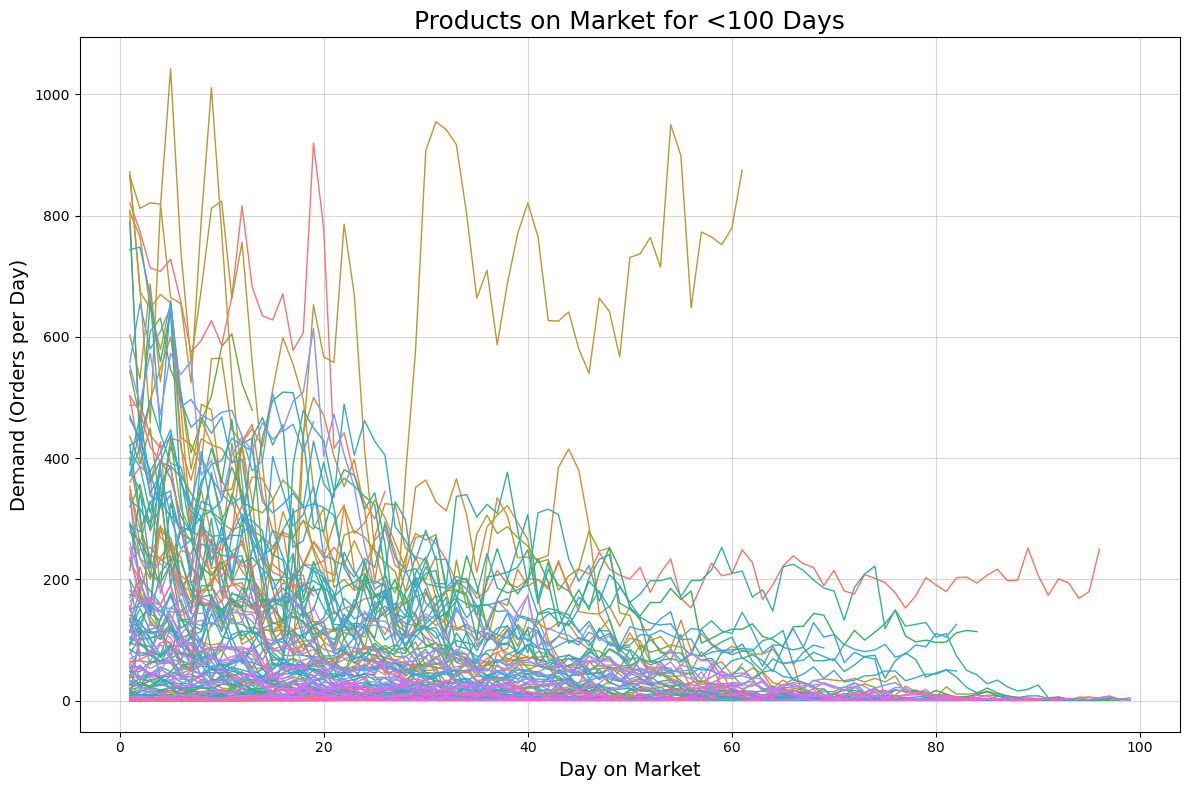

In [39]:
# Demand trajectories for every product across the full dataset
all_products_df['date'] = pd.to_datetime(all_products_df['date'])

# Count daily demand per product and index each day on market
daily_demand = (
    all_products_df.groupby(['product_name', 'date'])
    .size()
    .reset_index(name='demand')
    .sort_values(['product_name', 'date'])
)
daily_demand['market_day'] = daily_demand.groupby('product_name').cumcount() + 1

# Split products by mean daily demand
threshold = 500
mean_demand = (
    daily_demand.groupby('product_name')['demand']
    .mean()
    .rename('mean_daily_demand')
)
high_demand_products = mean_demand[mean_demand > threshold].index
low_demand_products = mean_demand[mean_demand <= threshold].index

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)
plot_configs = [
    ('High-demand products (>500 avg orders/day)', high_demand_products, axes[0]),
    ('Other products (≤500 avg orders/day)', low_demand_products, axes[1])
]

for title, product_idx, ax in plot_configs:
    subset = daily_demand[daily_demand['product_name'].isin(product_idx)]
    if subset.empty:
        ax.text(0.5, 0.5, 'No products in this category', ha='center', va='center')
        ax.axis('off')
        continue
    sns.lineplot(
        data=subset,
        x='market_day',
        y='demand',
        hue='product_name',
        linewidth=1,
        legend=False,
        ax=ax
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Day on Market', fontsize=12)
    ax.set_ylabel('Demand (Orders per Day)', fontsize=12)
    ax.grid(alpha=0.5)

plt.suptitle('Daily Demand Trajectories Split by Mean Daily Demand', fontsize=20)
plt.tight_layout()
plt.savefig('demand_trajectories_split_by_mean_daily_demand.pdf', dpi=300)
plt.show();

# Products that exist fewer than 100 days on market
longevity = daily_demand.groupby('product_name')['market_day'].max()
short_lived_products = longevity[longevity < 100].index

plt.figure(figsize=(12, 8))
short_subset = daily_demand[daily_demand['product_name'].isin(short_lived_products)]
if short_subset.empty:
    plt.text(0.5, 0.5, 'No products with <100 days on market', ha='center', va='center')
    plt.axis('off')
else:
    sns.lineplot(
        data=short_subset,
        x='market_day',
        y='demand',
        hue='product_name',
        linewidth=1,
        legend=False
    )
    plt.title('Products on Market for <100 Days', fontsize=18)
    plt.xlabel('Day on Market', fontsize=14)
    plt.ylabel('Demand (Orders per Day)', fontsize=14)
    plt.grid(alpha=0.5)

plt.tight_layout()
plt.savefig('products_on_market_for_less_than_100_days.pdf', dpi=300)
plt.show();


/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


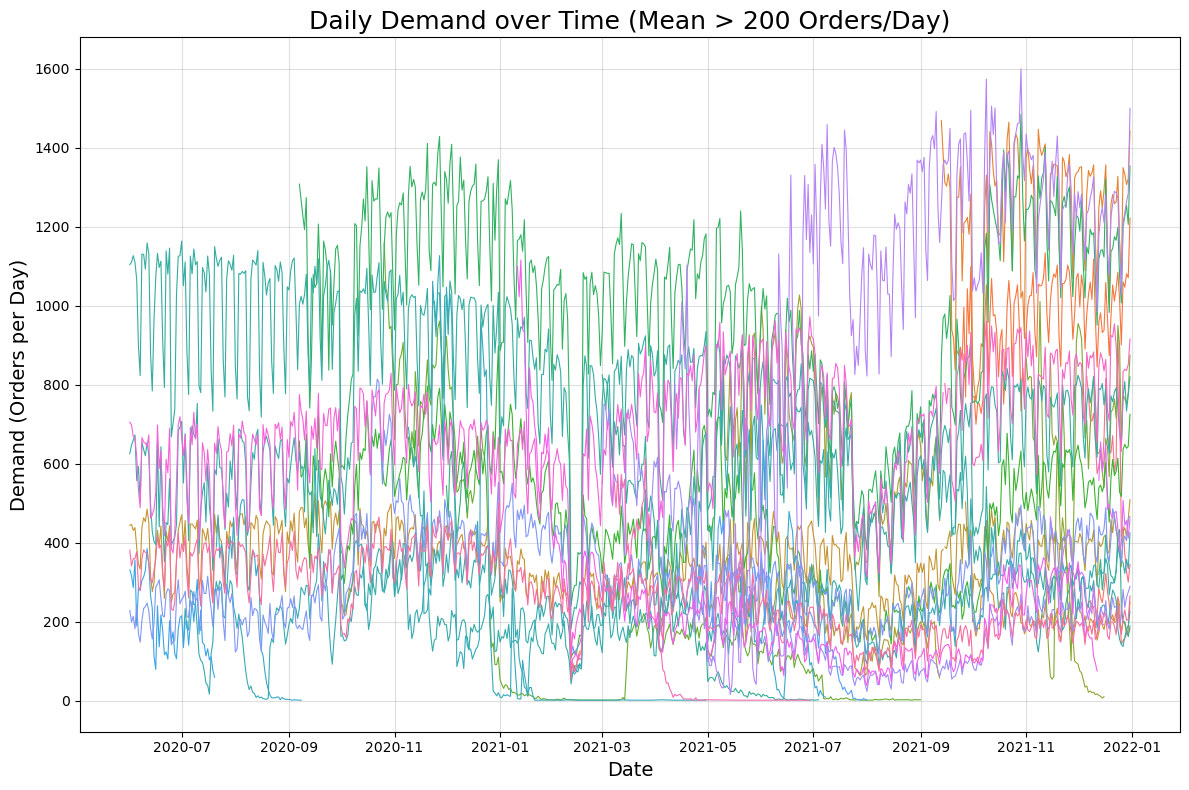

/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


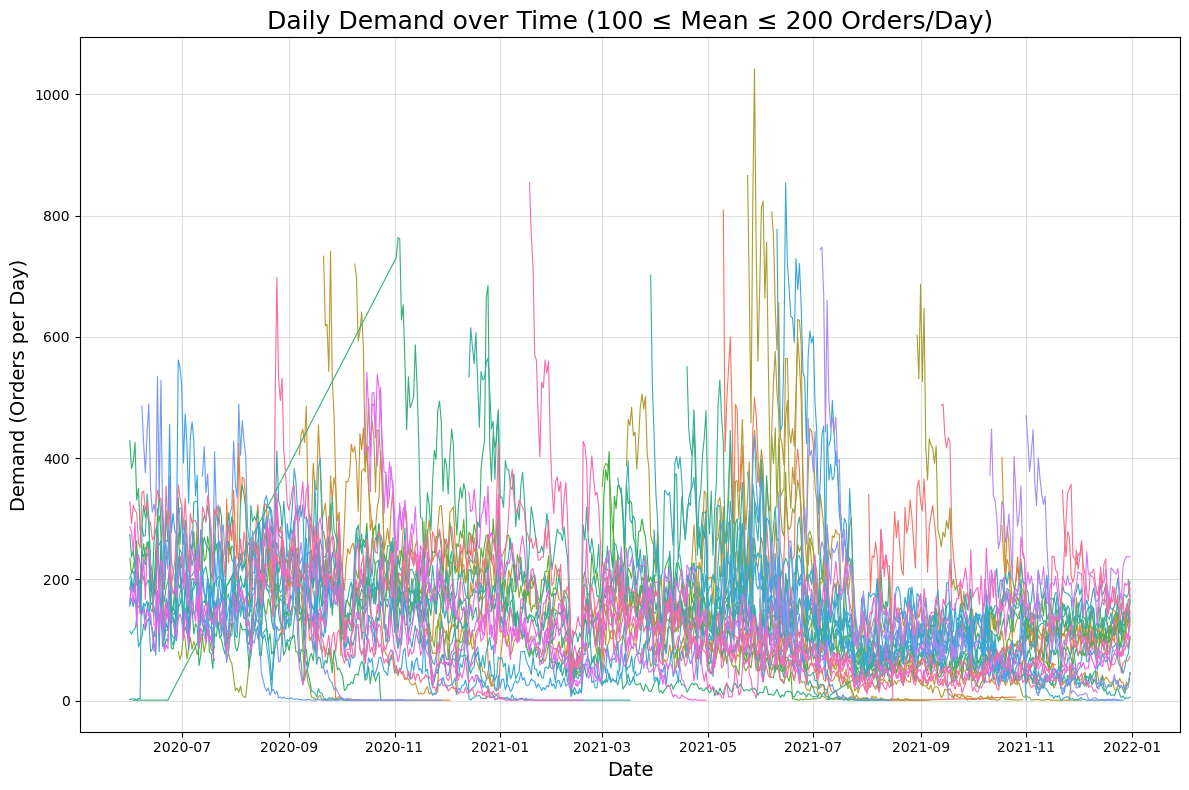

/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


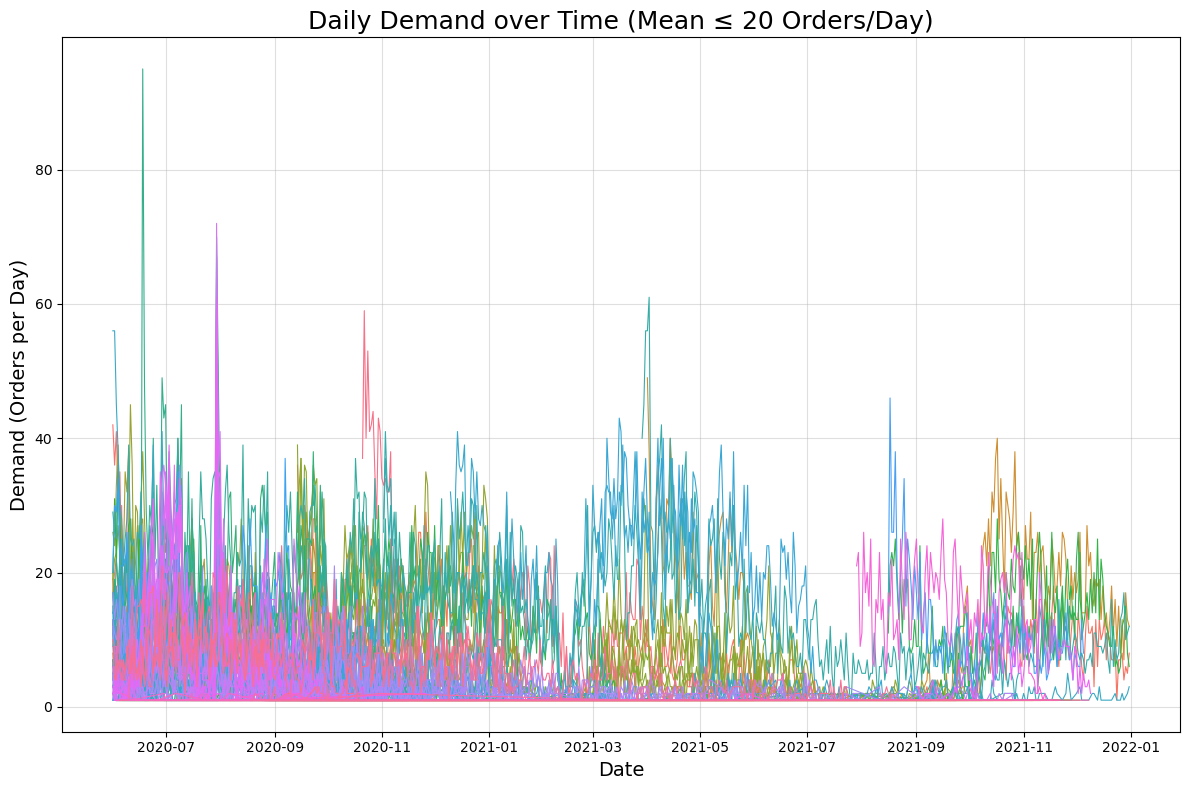

In [40]:
# Daily demand trajectories on actual calendar dates (mean demand > 200)
high_mean_products = mean_demand[mean_demand > 200].index
calendar_subset = daily_demand[daily_demand['product_name'].isin(high_mean_products)]

plt.figure(figsize=(12, 8))
if calendar_subset.empty:
    plt.text(0.5, 0.5, 'No products exceed 200 avg orders/day', ha='center', va='center')
    plt.axis('off')
else:
    sns.lineplot(
        data=calendar_subset,
        x='date',
        y='demand',
        hue='product_name',
        linewidth=0.8,
        legend=False
    )
    plt.title('Daily Demand over Time (Mean > 200 Orders/Day)', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Demand (Orders per Day)', fontsize=14)
    plt.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('demand_trajectories_mean_gt_200.pdf', dpi=300)
plt.show();

# Daily demand trajectories for products with mean <= 200
low_mean_products = mean_demand[(mean_demand >= 100) & (mean_demand <= 200)].index
calendar_subset_low = daily_demand[daily_demand['product_name'].isin(low_mean_products)]

plt.figure(figsize=(12, 8))
if calendar_subset_low.empty:
    plt.text(0.5, 0.5, 'No products at or below 200 avg orders/day', ha='center', va='center')
    plt.axis('off')
else:
    sns.lineplot(
        data=calendar_subset_low,
        x='date',
        y='demand',
        hue='product_name',
        linewidth=0.8,
        legend=False
    )
    plt.title('Daily Demand over Time (100 ≤ Mean ≤ 200 Orders/Day)', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Demand (Orders per Day)', fontsize=14)
    plt.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('demand_trajectories_mean_100_200.pdf', dpi=300)
plt.show();

# Daily demand trajectories for products with mean <= 100
low_mean_products = mean_demand[(mean_demand <= 20)].index
calendar_subset_low = daily_demand[daily_demand['product_name'].isin(low_mean_products)]

plt.figure(figsize=(12, 8))
if calendar_subset_low.empty:
    plt.text(0.5, 0.5, 'No products at or below 200 avg orders/day', ha='center', va='center')
    plt.axis('off')
else:
    sns.lineplot(
        data=calendar_subset_low,
        x='date',
        y='demand',
        hue='product_name',
        linewidth=0.8,
        legend=False
    )
    plt.title('Daily Demand over Time (Mean ≤ 20 Orders/Day)', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Demand (Orders per Day)', fontsize=14)
    plt.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('demand_trajectories_mean_20.pdf', dpi=300)
plt.show();
